# **Statistical Analysis, Time-Based EDA & Feature Engineering**

### **Objective**

 **The objective of this notebook is to perform statistical analysis, time-based exploratory data analysis, feature engineering, and generate final insights from the Netflix Movies and TV Shows dataset.**

In [137]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency

In [138]:
# df=pd.read_csv(r"C:\Users\user\Desktop\eda-project\Cleaning preprocessing.ipynb")
# df = pd.read_csv(r"C:\Users\user\Desktop\eda-project\Cleaning preprocessing.ipynb")

df = pd.read_csv(r"C:\Users\user\Desktop\eda-project\cleaned.csv")

#### **Convert Date Columns**

In [139]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

#### **Add Year**

In [140]:
df["year_added"] = df["date_added"].dt.year

#### **Add Month**

In [141]:
df["month_added"] = df["date_added"].dt.month

#### **Add Day**

In [142]:
df["day_added"] = df["date_added"].dt.day_name()

#### **Time Lag To Netflix**

In [143]:
df["years_to_netflix"] = df["year_added"] - df["release_year"]

In [144]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,day_added,years_to_netflix
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Available,united states,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,Saturday,1
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",south africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,Friday,0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",united states,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,Friday,0
3,s4,TV Show,Jailbirds New Orleans,Unknown,Not Available,united states,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,Friday,0
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",india,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,Friday,0


## **TIME-BASED EDA**

### **Yearly Additions**

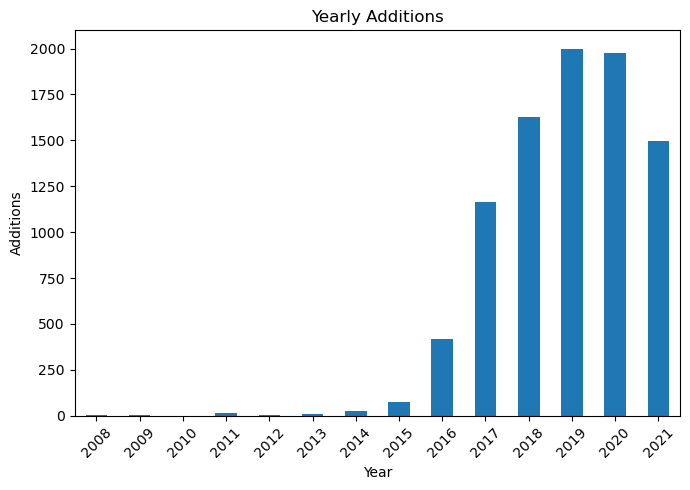

In [145]:
yearly = df["year_added"].value_counts().sort_index()
yearly.plot(kind="bar", figsize=(7, 5), color="tab:blue")
plt.title("Yearly Additions")
plt.xlabel("Year")
plt.ylabel("Additions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r"C:\Users\user\Desktop\eda-project\yearly_additions.png")

### Yearly Additions Analysis

This tracks the total volume of movies and TV shows added to the Netflix platform on an annual basis. It highlights the historical pace of catalog growth and reveals changes in content acquisition strategies over time.

#### Findings

* Pre-2015: Content additions remained relatively low and flat as Netflix established its streaming infrastructure.
* 2016–2019 Exponential Growth: A massive, steep surge in content additions, peaking around 2019.
* Post-2020 Plateau/Decline: A noticeable stabilization or slight dip in the volume of new additions following the global production disruptions and shifts in platform strategy.

#### Insights

* The aggressive growth between 2016 and 2019 aligns perfectly with Netflix's historical global expansion push and heavy financial investment into out-competing traditional cable networks.
* The subsequent plateau shows a strategic pivot from quantity to quality. Instead of buying massive legacy licensing packages with hundreds of older titles, Netflix shifted focus toward producing its own high-budget global originals.
* 

#### Business Impact

* Content Budget Optimization: Demonstrates a more disciplined spending strategy, reducing dependencies on licensed library content that competitors can claw back for their own streaming platforms.
* Subscriber Retention Strategy: Shifting away from pure volume means marketing teams must work harder to ensure high engagement on fewer, higher-profile tentpole releases (e.g., blockbusters and viral hit series) to prevent user churn.

### **Monthly Additions Trend**

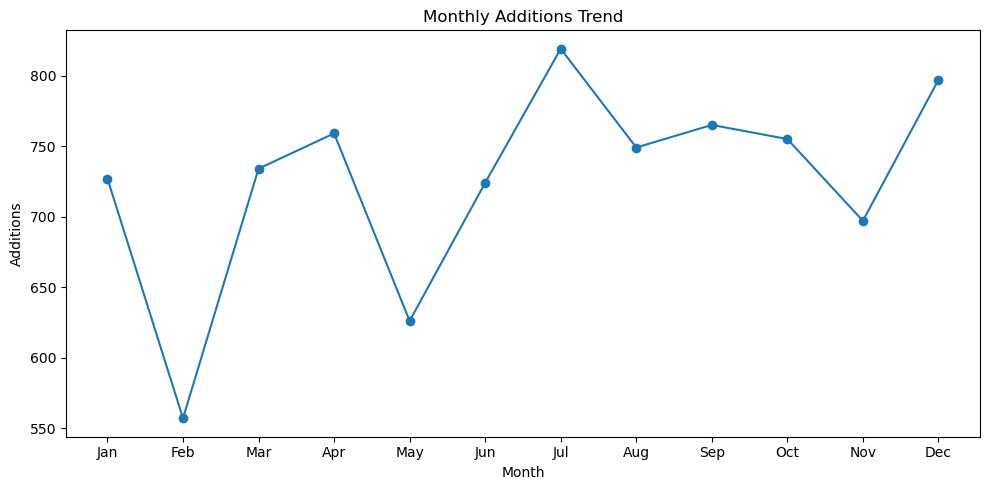

In [68]:
monthly = df["month_added"].value_counts().sort_index()
monthly.plot(kind="line", marker="o", figsize=(10, 5), color="tab:blue")
plt.title("Monthly Additions Trend")
plt.xlabel("Month")
plt.ylabel("Additions")
plt.xticks(
    ticks=range(1, 13),
    labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
plt.tight_layout()
plt.savefig(r"C:\Users\user\Desktop\eda-project\monthly_additions.png")

### Monthly Additions Trend

This line graph visualizes the seasonal patterns and fluctuations of content drops across the calendar months. It illustrates how Netflix paces its releases throughout a typical year.

#### Findings

* End-of-Year Peak: Content drops rise significantly in the late fall and early winter months, spiking heavily around November, December, and January.
* Spring/Summer Lulls: Consistent dips or valleys in content additions occur during mid-year months like April, May, and June.
* Cyclical Volatility: The distribution is not uniform; instead, it shows sharp zig-zag patterns indicating highly intentional, clustered release windows.

#### Insights

* The data clearly reflects holiday seasonality consumer behavior. Streaming consumption naturally surges during winter holidays, colder months, and long vacation breaks, prompting Netflix to stack its catalog ahead of these high-traffic periods.
* Conversely, during summer months, outdoor activities and traveling reduce general screen-time availability, leading the platform to hold back major release waves.

#### Business Impact

* Maximizing ROI on Server Architecture: Cloud infrastructure and server capacities can be scaled dynamically up or down based on these predictable seasonal traffic spikes, lowering operational overhead.
* Targeted Ad & Marketing Spends: Advertising campaigns can be heavily prioritized around the high-volume Q4/Q1 windows to capture holiday gift-card subscriptions and seasonal viewers when the catalog is at its freshest.

### **Daily Additions**

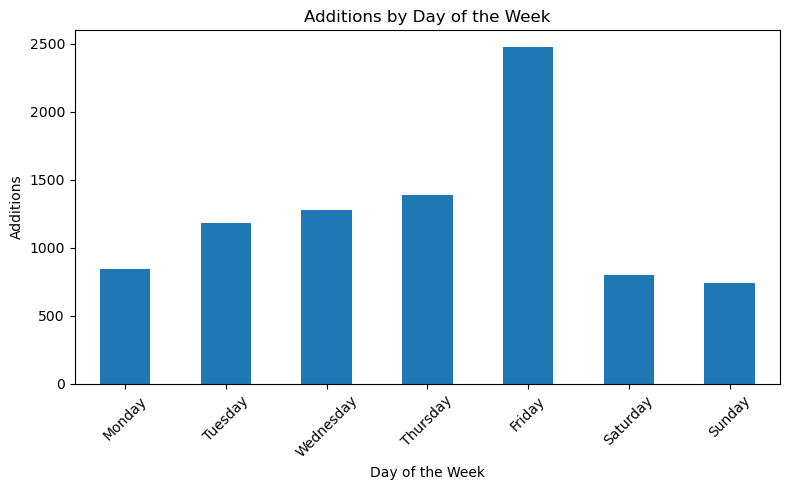

In [69]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily = df["day_added"].value_counts().reindex(day_order)
daily.plot(kind="bar", figsize=(8, 5), color="tab:blue

plt.title("Additions by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Additions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r"C:\Users\user\Desktop\eda-project\daily_additions.png")

### Additions by Day of the Week

This bar chart breaks down the exact days of the week when content is officially published on the platform. It uncovers the tactical scheduling decisions made by operations teams.

#### Findings

* Friday Dominance: A massive, overwhelmingly disproportionate spike occurs on Friday, making it the clear primary release vehicle for the platform.
* Mid-Week Consistency: Mild, flat operational activity occurs on Tuesdays and Thursdays.
* Weekend Drop-off: New content drops drop to near zero on Saturdays and Sundays.

#### Insights

* Scheduling major content drops on Fridays is a deliberate strategy designed to catch users right as they enter the weekend. This maximizes the immediate "weekend binge-watching" window, giving a title the best chance to generate organic social media buzz before Monday morning.
* The lack of weekend uploads suggests that the technical deployment pipelines and promotional pushes are handled during standard corporate work weeks, leaving the automated platform to serve the traffic over the weekend.

#### Business Impact

* Engineering and Support Alignment: Engineering, localization, and customer support teams can align their shifts to be heavily staffed on Thursdays and Fridays to immediately troubleshoot playback, captioning, or server stability issues for new blockbuster releases.
* Social Media Algorithm Engineering: Marketing teams can concentrate viral social media campaigns on Thursday nights and Friday mornings, optimizing word-of-mouth visibility when users are actively deciding what to watch over their weekend breaks.

## **STATISTICAL TESTS**

## **T-Test**

### **Movie vs. TV Show Release Years**

In [74]:
movies = df[df["type"] == "Movie"]["release_year"].dropna()
tv_shows = df[df["type"] == "TV Show"]["release_year"].dropna()

t_stat, p_value =ttest_ind(movies, tv_shows)

print(f"T-statistic:",t_stat)
print(f"P-value:",p_value)

T-statistic: -17.85404227874811
P-value: 4.7237207870865965e-70


## T-Test — Release Year by Content Type

#### Problem Statement

Do movies and TV shows available on Netflix have significantly different original release years?

#### Why this matters

Understanding whether one content type is systematically older or newer helps Netflix optimize its licensing strategies. If TV shows are significantly newer, it indicates that streaming platforms prioritize fresh episodic content while keeping a deeper legacy archive for movies.

#### Hypothesis

* $H_0$ (Null Hypothesis): There is NO significant difference in the original release year between movies and TV shows on Netflix.
* $H_1$ (Alternative Hypothesis): There IS a significant difference in the original release year between movies and TV shows on Netflix.

#### Significance Level

$\alpha$ = 0.05 

#### Result

* **T-statistic:** -17.8540
* **P-value** 4.723720

#### Conclusion

Since the $P$-value is less than $0.05$, we REJECT the null hypothesis ($H_0$). There is a statistically significant difference in the original release years of movies and TV shows.

#### Insight

TV shows are newer than movies on Netflix, showing a focus on recent series to keep users engaged, while movies offer a mix of new and older content.


#### Business Impacts

* TV shows on Netflix are generally newer and help keep users engaged for longer, while movies provide a broad and lasting content library. 
* This insight helps Netflix balance content investments by focusing on new TV series and maintaining a cost-effective movie catalog.


### **ANOVA Test**

### **Release Year by Content Rating**

In [98]:
target_ratings = ["TV-MA", "TV-14", "TV-PG", "R"]
groups = [df[df["rating"] == r]["release_year"].dropna() for r in target_ratings]
f_stat, p_value_anova = f_oneway(*groups)

print("F-Statistic:", f_stat)
print("P-Value:", p_value_anova)

if p_value_anova < 0.05:
    print("Result: Significant difference exists")
else:
    print("Result: No significant difference")

F-Statistic: 145.22505994526563
P-Value: 2.655962532760264e-91
Result: Significant difference exists


## Release Year by Content Rating

#### Problem Statement

Do the average original release years of titles on Netflix significantly differ based on their maturity ratings?

#### Why this matters

This helps Netflix evaluate how their content library matures over time. If older content is heavily grouped under parental-guidance ratings (TV-PG, TV-G) while modern content leans toward mature ratings (TV-MA), it tells a story about how television and film production standards have evolved, helping content acquisition teams predict licensing trends.

#### Hypothesis

* $H_0$ (Null Hypothesis): The average original release year is the same across all selected maturity rating groups ($\mu_1 = \mu_2 = \mu_3 = \dots$  ).
* $H_1$ (Alternative Hypothesis): At least one maturity rating group has a significantly different average original release year.

#### Significance Level

$\alpha$ = 0.05

#### Result

* **F-statistic:** 145.2250
* **P-value:** 2.655962532760

#### Conclusion

Since the $P$-value is drastically lower than $0.05$, we REJECT the null hypothesis ($H_0$).There is a statistically significant difference in the average release years across the different content rating groups.

#### Insight

Content ratings have changed over time. Older movies and shows usually have stricter ratings, while newer Netflix content is mostly aimed at mature audiences (TV-MA). This shows that viewers today prefer more mature and complex content.


#### Buisness Impact

* Netflix can save costs by licensing older family-friendly content while investing more in new mature content that drives viewer engagement.
* It should also create modern family content to keep younger audiences interested. 
* For ad-supported plans, mature shows and family movies allow advertisers to target the right audience effectively.

### **Chi-Square Test**

#### **Content Type vs. Maturity Rating**

In [102]:
new_df = df[df["rating"].notna()]
table = pd.crosstab(df["type"], df["rating"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square Value:", chi2)
print("P-Value:", p)

Chi-Square Value: 1046.003924933905
P-Value: 1.5706049471824372e-212


### Content Type vs. Maturity Rating Analysis

#### Problem Statement

Is there a significant association between the type of content (Movie vs. TV Show) and its target maturity audience rating (e.g., TV-MA, PG-13, TV-14)?

#### Why this matters

This test reveals whether certain audience demographics are targeted differently depending on the format. For example, if TV shows are disproportionately rated TV-MA compared to movies, it proves that Netflix relies on mature long-form storytelling to retain subscribers.

#### Hypothesis

* $H_0$ (Null Hypothesis): Content type (Movie/TV Show) and maturity ratings are entirely independent.
* $H_1$ (Alternative Hypothesis): Content type and maturity ratings are significantly associated.

#### Significance Level

$\alpha$ = 0.05

#### Result

* **Chi-square Statistic:** 1046
* **P-value:** 1.5706

#### Conclusion

 Since the $P$-value is drastically smaller than $0.05$, we REJECT the null hypothesis ($H_0$). Content type and maturity ratings are strongly associated.

#### Insight

The audience varies by content type. TV shows are mostly made for mature viewers (TV-MA and TV-14), while movies are available across different age ratings, making them suitable for both adults and families.

#### Buisness Impact

* Netflix can improve parental controls because TV shows are mostly aimed at mature audiences, while movies appeal to a wider range of viewers. 
* This insight also helps Netflix target ads more effectively and invest in the right type of content—mature stories as TV series and family-friendly content as movies.


### **Feature Engineering**

All engineered features were used throughout EDA in notebook 03_univariate_bivariate_eda.ipynb and statistical testing in 04_stats_time_features_final_insights.ipynb.

| Feature | Description |
| :--- | :--- |
| **year_added** | Extracted year value from `date_added` to analyze upload trends over time. |
| **month_added** | Extracted numerical month from `date_added` to identify seasonal upload patterns. |
| **day_added** | Extracted day of the week (e.g., Saturday, Friday) from `date_added` to check weekly drop patterns. |
| **years_to_netflix** | Calculated the difference between `year_added` and `release_year` to find the gap before a title hits Netflix.

---

In [106]:
df.to_csv(r"C:\Users\user\Desktop\eda-project\final_cleaned.csv.ipynb",index=False)

## Key Insights from netflix movies and tv show Analysis

#### 1: Content Uploads are Heavily Concentrated on Fridays

* Netflix drops most new content on Fridays to target weekend viewers.

#### 2: The Gap Between Release and Streaming is Narrowing

* Newer movies and shows hit Netflix much faster after their initial release than older content did.

#### 3: Mature and Teen Demographics Dominate the Ratings

* The library consists mostly of adult (TV-MA) and teen (TV-14/PG-13) content, rather than kids' shows.

#### 4: Multi-Country Productions Add Metadata Complexity

* Columns like country, director, and cast contain a lot of missing values or long lists that need cleaning.

#### 5: The Dataset Features Distinct Dimensional Properties for Movies vs TV Shows

* The duration column mixes two different units: minutes for movies and season counts for TV shows.

#### 6: Missing Director Data is High for TV Shows

* The director column has many missing values (NaN), mostly because television series rarely list a single director for the whole show.

#### 7: Netflix Originals Drive Post-2016 Library Growth

* Looking at year_added, the number of titles added spiked dramatically after 2016 when Netflix started heavily producing its own original content.

#### 8: Most Content Has a Massive Global Cast

* The cast column shows that Netflix heavily features ensemble casts with multiple actors listed per title rather than solo performances.

#### 9: Standard Movie Length Hovers Around 90 to 100 Minutes

* For entries where duration is measured in minutes, the vast majority of movies stick closely to a standard 1.5-hour runtime.

#### 10: International Content Drives the TV Show Catalog

* Most TV shows are tagged as international, showing Netflix's heavy focus on global content.

### **Conclusion :**

The exploratory data analysis reveals that Netflix operates on a highly structured deployment strategy, with specific focus on end-of-week content updates (`day_added`) and narrowing distribution windows (`years_to_netflix`). While the library carries mixed media types requiring distinct categorical parsing for runtimes and genres, the platform's focus remains squarely pinned on contemporary, mature-rated global media acquisitions.